# Healthcare Drug Safety Analysis: Data Exploration

## Setup

### Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

### Load data

In [2]:
df = pd.read_csv("data/raw_adverse_events.csv")

### Data Color

In [3]:
drug_colors = {
    "atorvastatin": "#E76F51",
    "ibuprofen":    "#2A9D8F",
    "metformin":    "#264653",
}

## Data Overview

### Dataset

In [4]:
print(df.shape)
df.head()

(24333, 17)


,safetyreportid,queried_drug,drug_names_on_report,drug_routes_on_report,reaction_term,reaction_outcome,serious,seriousnessdeath,seriousnesshospitalization,seriousnesslifethreatening,seriousnessdisabling,seriousnesscongenitalanomali,occurcountry,patient_sex,patient_age,patient_age_unit,receivedate
0,10003641,metformin,DEPAKOTE; INVEGA; METFORMIN; COGENTIN; BISOPRO...,048,Medication residue present,3.0,2,0,0,0,0,0,US,1.0,41.0,801.0,20140312
1,10003642,metformin,TOFACITINIB CITRATE; TOFACITINIB CITRATE; METH...,048; 048; 048; 048; 048; 048; 048; 048; 048; 0...,Osteomyelitis,1.0,1,0,0,0,0,0,US,2.0,66.0,801.0,20140312
2,10003647,metformin,METFORMIN; COZAAR; ACZ885; WARAN; TROMBYL; AML...,048; 048; 058; 048; 048; 048,Erysipelas,5.0,1,1,1,0,0,0,SE,1.0,74.0,801.0,20140312
3,10003647,metformin,METFORMIN; COZAAR; ACZ885; WARAN; TROMBYL; AML...,048; 048; 058; 048; 048; 048,Sepsis,5.0,1,1,1,0,0,0,SE,1.0,74.0,801.0,20140312
4,10003803,metformin,DEPAKOTE; LISINOPRIL/HYDROCHLOROTHIAZIDE; GLIP...,NaN,Balance disorder,2.0,2,0,0,0,0,0,US,1.0,NaN,NaN,20140312


### Data types

In [5]:
df.dtypes

safetyreportid                    int64
queried_drug                        str
drug_names_on_report                str
drug_routes_on_report               str
reaction_term                       str
reaction_outcome                float64
serious                           int64
seriousnessdeath                  int64
seriousnesshospitalization        int64
seriousnesslifethreatening        int64
seriousnessdisabling              int64
seriousnesscongenitalanomali      int64
occurcountry                        str
patient_sex                     float64
patient_age                     float64
patient_age_unit                float64
receivedate                       int64
dtype: object

## Data Cleaning

### Type casting

In [6]:
numeric_cols = [
    "serious", "seriousnessdeath", "seriousnesshospitalization",
    "seriousnesslifethreatening", "seriousnessdisabling",
    "seriousnesscongenitalanomali", "reaction_outcome",
    "patient_sex", "patient_age",
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Date
df["receivedate"] = pd.to_datetime(df["receivedate"], format="%Y%m%d", errors="coerce")

df.dtypes

safetyreportid                           int64
queried_drug                               str
drug_names_on_report                       str
drug_routes_on_report                      str
reaction_term                              str
reaction_outcome                       float64
serious                                  int64
seriousnessdeath                         int64
seriousnesshospitalization               int64
seriousnesslifethreatening               int64
seriousnessdisabling                     int64
seriousnesscongenitalanomali             int64
occurcountry                               str
patient_sex                            float64
patient_age                            float64
patient_age_unit                       float64
receivedate                     datetime64[us]
dtype: object

### Patient age (unit conversion)

In [7]:
df["patient_age"].describe() 

count    20695.000000
mean       124.096352
std       1317.416265
min          0.000000
25%         50.000000
50%         62.000000
75%         71.000000
max      29866.000000
Name: patient_age, dtype: float64

**Problem:** `patient_age` cannot be used on its own. FAERS stores age as two
separate fields: the number (`patient_age`) and its unit (`patient_age_unit`).

| Code | Unit |
|---|---|
| 800 | Decade |
| 801 | Year |
| 802 | Month |
| 803 | Week |
| 804 | Day |
| 805 | Hour |

The same number means very different ages depending on the unit. For example,
`6` can be 6 years, 6 months or 6 weeks, and `29866` days is about 82 years.

**Evidence:** `patient_age.describe()` gives impossible values:

| | Mean | Max |
|---|---|---|
| `patient_age` (mixed units) | 124 | 29,866 |

Nobody is 29,866 years old. Records given in days, weeks or months are being
read as if they were years.

**Fix:** convert every age to years (`patient_age_years`) using the unit code:
`patient_age_years = patient_age × conversion factor` (year = 1, month = 1/12,
week = 1/52, day = 1/365, ...).

**Result:** after conversion, the mean is 58 years and the maximum is 98. The
25th, 50th and 75th percentiles (50, 62, 71) did not change, so most records
were already in years. Only a small number of records in other units distorted
the mean and maximum. The number of rows with an age (20,695) also did not
change, so the conversion did not add missing values.

**Decision:** use `patient_age_years` in every age analysis and never
`patient_age`. Rows with no age stay missing (about 14%) and are excluded only
from age-specific analyses.

In [8]:
AGE_UNIT_TO_YEARS = {
    800: 10,       # decade
    801: 1,        # year
    802: 1 / 12,   # month
    803: 1 / 52,   # week
    804: 1 / 365,  # day
    805: 1 / 8760, # hour
}

df["patient_age_unit"] = pd.to_numeric(df["patient_age_unit"], errors="coerce")
df["patient_age_years"] = df["patient_age"] * df["patient_age_unit"].map(AGE_UNIT_TO_YEARS)

df["patient_age_years"].describe()

count    20695.000000
mean        58.237293
std         18.205908
min          0.000000
25%         50.000000
50%         62.000000
75%         71.000000
max         98.000000
Name: patient_age_years, dtype: float64

### Duplicate rows

The raw CSV preview showed what looked like exact duplicate rows for the
same report. Confirm how widespread this is before deciding whether to drop
them, dropping blindly could also hide genuine repeated reactions.

In [9]:
#find report id has more than one queried drugs
#e.g. ID 200, metformin, "Nausea" and ID 200, atorvastatin, "Nausea"
overlap = df.groupby("safetyreportid")["queried_drug"].nunique()
print(f"{(overlap > 1).sum()} reports appear under more than one drug")

exact_dupes = df.duplicated().sum()
print(f"Fully identical rows: {exact_dupes} ({exact_dupes / len(df):.1%} of all rows)")

same_key = df.duplicated(subset=["safetyreportid", "queried_drug", "reaction_term"]).sum()
print(f"Same report + same drug + same reaction: {same_key} ({same_key / len(df):.1%})")

263 reports appear under more than one drug
Fully identical rows: 220 (0.9% of all rows)
Same report + same drug + same reaction: 320 (1.3%)


In [10]:
import numpy as np

key = ["safetyreportid", "queried_drug", "reaction_term"]

# 1. Flag events whose repeated rows disagree on the outcome
df["outcome_conflict"] = df.groupby(key)["reaction_outcome"].transform("nunique") > 1

# 2. The outcome is unreliable for those events, so set it to missing
df.loc[df["outcome_conflict"], "reaction_outcome"] = np.nan

# 3. Keep one row per event, preferring a row that has an outcome
before = len(df)
df = (
    df.sort_values("reaction_outcome", na_position="last")
      .drop_duplicates(subset=key)
      .sort_index()
)
print(f"Dropped {before - len(df)} duplicate rows ({before} -> {len(df)})")
print(f"Events with conflicting outcomes: {df['outcome_conflict'].sum()}")

Dropped 320 duplicate rows (24333 -> 24013)
Events with conflicting outcomes: 89


The same reaction can appear twice in one report and drug. When the two
entries disagree on the outcome, we keep one row (the reaction still counts),
set the outcome to missing and flag it as `outcome_conflict`. Identical
copies are simply removed.

### Missing values

In [11]:
df.isna().sum().sort_values(ascending=False)

reaction_outcome                5014
occurcountry                    4078
drug_routes_on_report           3751
patient_age_years               3582
patient_age_unit                3582
patient_age                     3582
patient_sex                      232
safetyreportid                     0
seriousnesscongenitalanomali       0
receivedate                        0
seriousnesslifethreatening         0
seriousnessdisabling               0
queried_drug                       0
seriousnesshospitalization         0
seriousnessdeath                   0
serious                            0
reaction_term                      0
drug_names_on_report               0
outcome_conflict                   0
dtype: int64

In [12]:
for col in ["occurcountry", "drug_routes_on_report"]:
    df[col] = df[col].astype(object).fillna("Unknown")

In [13]:
df.shape

(24013, 19)

In [14]:
df

,safetyreportid,queried_drug,drug_names_on_report,drug_routes_on_report,reaction_term,reaction_outcome,serious,seriousnessdeath,seriousnesshospitalization,seriousnesslifethreatening,seriousnessdisabling,seriousnesscongenitalanomali,occurcountry,patient_sex,patient_age,patient_age_unit,receivedate,patient_age_years,outcome_conflict
0,10003641,metformin,DEPAKOTE; INVEGA; METFORMIN; COGENTIN; BISOPRO...,048,Medication residue present,3.0,2,0,0,0,0,0,US,1.0,41.0,801.0,2014-03-12,41.0,False
1,10003642,metformin,TOFACITINIB CITRATE; TOFACITINIB CITRATE; METH...,048; 048; 048; 048; 048; 048; 048; 048; 048; 0...,Osteomyelitis,1.0,1,0,0,0,0,0,US,2.0,66.0,801.0,2014-03-12,66.0,False
2,10003647,metformin,METFORMIN; COZAAR; ACZ885; WARAN; TROMBYL; AML...,048; 048; 058; 048; 048; 048,Erysipelas,5.0,1,1,1,0,0,0,SE,1.0,74.0,801.0,2014-03-12,74.0,False
3,10003647,metformin,METFORMIN; COZAAR; ACZ885; WARAN; TROMBYL; AML...,048; 048; 058; 048; 048; 048,Sepsis,5.0,1,1,1,0,0,0,SE,1.0,74.0,801.0,2014-03-12,74.0,False
4,10003803,metformin,DEPAKOTE; LISINOPRIL/HYDROCHLOROTHIAZIDE; GLIP...,Unknown,Balance disorder,2.0,2,0,0,0,0,0,US,1.0,NaN,NaN,2014-03-12,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24328,10210205,atorvastatin,METOPROLOL TARTRATE (METOPROLOL TARTRATE) (MET...,Unknown,Pruritus,NaN,1,0,1,0,0,0,Unknown,2.0,62.0,801.0,2014-05-28,62.0,False
24329,10210205,atorvastatin,METOPROLOL TARTRATE (METOPROLOL TARTRATE) (MET...,Unknown,Rash generalised,NaN,1,0,1,0,0,0,Unknown,2.0,62.0,801.0,2014-05-28,62.0,False
24330,10210205,atorvastatin,METOPROLOL TARTRATE (METOPROLOL TARTRATE) (MET...,Unknown,Drug ineffective,NaN,1,0,1,0,0,0,Unknown,2.0,62.0,801.0,2014-05-28,62.0,False
24331,10210286,atorvastatin,MULTAQ; ATORVASTATIN; WARFARIN; LANSOPRAZOLE; ...,048,Alanine aminotransferase increased,1.0,1,0,0,0,0,0,GB,1.0,70.0,801.0,2014-06-02,70.0,False


## Feature Preparation

### Drug count (multi-drug reports)
`drug_names_on_report` lists every drug on a report. Count the **distinct**
drugs so we can see how many reports involve more than one drug.

In [15]:
df["drug_count"] = df["drug_names_on_report"].apply(
    lambda s: len({d.strip() for d in s.split(";") if d.strip()})
)
df["is_multi_drug"] = df["drug_count"] > 1

print(df["drug_count"].describe())
print(f"Reports rows with more than one drug: {df['is_multi_drug'].mean():.1%}")

count    24013.000000
mean         9.240661
std          7.084331
min          1.000000
25%          4.000000
50%          8.000000
75%         12.000000
max         59.000000
Name: drug_count, dtype: float64
Reports rows with more than one drug: 94.6%


### Route codes to labels
Route codes come from the openFDA field documentation
(https://open.fda.gov/apis/drug/event/searchable-fields/).
A report can list several routes, so we keep a route only when exactly one
distinct code appears; otherwise the label is "Multiple routes".
Code 065 (reporter said unknown) and empty values are different things.

In [16]:
ROUTE_LABELS = {
    "001": "Auricular (otic)", "002": "Buccal", "003": "Cutaneous", "004": "Dental",
    "005": "Endocervical", "006": "Endosinusial", "007": "Endotracheal", "008": "Epidural",
    "009": "Extra-amniotic", "010": "Hemodialysis", "011": "Intra corpus cavernosum",
    "012": "Intra-amniotic", "013": "Intra-arterial", "014": "Intra-articular",
    "015": "Intra-uterine", "016": "Intracardiac", "017": "Intracavernous",
    "018": "Intracerebral", "019": "Intracervical", "020": "Intracisternal",
    "021": "Intracorneal", "022": "Intracoronary", "023": "Intradermal",
    "024": "Intradiscal (intraspinal)", "025": "Intrahepatic", "026": "Intralesional",
    "027": "Intralymphatic", "028": "Intramedullar (bone marrow)", "029": "Intrameningeal",
    "030": "Intramuscular", "031": "Intraocular", "032": "Intrapericardial",
    "033": "Intraperitoneal", "034": "Intrapleural", "035": "Intrasynovial",
    "036": "Intratumor", "037": "Intrathecal", "038": "Intrathoracic", "039": "Intratracheal",
    "040": "Intravenous bolus", "041": "Intravenous drip",
    "042": "Intravenous (not otherwise specified)", "043": "Intravesical",
    "044": "Iontophoresis", "045": "Nasal", "046": "Occlusive dressing technique",
    "047": "Ophthalmic", "048": "Oral", "049": "Oropharyngeal", "050": "Other",
    "051": "Parenteral", "052": "Periarticular", "053": "Perineural", "054": "Rectal",
    "055": "Respiratory (inhalation)", "056": "Retrobulbar", "057": "Subconjunctival",
    "058": "Subcutaneous", "059": "Subdermal", "060": "Sublingual", "061": "Topical",
    "062": "Transdermal", "063": "Transmammary", "064": "Transplacental",
    "065": "Unknown (coded by reporter)", "066": "Urethral", "067": "Vaginal",
    "Unknown": "Not reported (missing)",   # the word we filled in for empty values
}

def distinct_routes(value):
    if pd.isna(value):
        return set()
    return {r.strip() for r in value.split(";") if r.strip()}

df["route_set"] = df["drug_routes_on_report"].apply(distinct_routes)
df["route_count"] = df["route_set"].apply(len)

# One code only when the report has exactly one distinct route
df["route_code"] = df["route_set"].apply(lambda s: next(iter(s)) if len(s) == 1 else None)
df["route_label"] = df["route_code"].map(ROUTE_LABELS)

df.loc[df["route_count"] == 0, "route_label"] = "Not reported (missing)"
df.loc[df["route_count"] > 1, "route_label"] = "Multiple routes"

# Safety check: a single code we could not decode should be investigated
single = df["route_count"] == 1
df.loc[single, "route_label"] = df.loc[single, "route_label"].fillna("Unrecognised code")
print("Unrecognised codes:", df.loc[df["route_label"] == "Unrecognised code", "route_code"].unique())

df = df.drop(columns="route_set")   # sets can't be hashed, so remove before any later duplicate checks
df["route_label"].value_counts()

Unrecognised codes: <StringArray>
[]
Length: 0, dtype: str


route_label
Oral                                     8274
Multiple routes                          7572
Not reported (missing)                   3751
Unknown (coded by reporter)              1844
Subcutaneous                              595
Intravenous (not otherwise specified)     506
Respiratory (inhalation)                  322
Intra-uterine                             286
Transdermal                               233
Intramuscular                             165
Topical                                    94
Transplacental                             93
Ophthalmic                                 63
Intravenous drip                           36
Intraocular                                36
Nasal                                      25
Subdermal                                  23
Vaginal                                    19
Intravenous bolus                          19
Sublingual                                 17
Other                                      13
Intrathecal           

### Reaction outcome code to labels

In [17]:
OUTCOME_LABELS = {
    1: "Recovered", 2: "Recovering", 3: "Not recovered",
    4: "Recovered with sequelae", 5: "Fatal", 6: "Unknown",
}

df["reaction_outcome_label"] = (
    df["reaction_outcome"].map(OUTCOME_LABELS).fillna("Not reported (missing)")
)
df.loc[df["outcome_conflict"], "reaction_outcome_label"] = "Conflicting reports"

df["reaction_outcome_label"].value_counts()

reaction_outcome_label
Unknown                    8870
Not reported (missing)     4925
Recovered                  4417
Not recovered              3156
Recovering                 1688
Fatal                       573
Recovered with sequelae     295
Conflicting reports          89
Name: count, dtype: int64

### Report-level table
The table has one row per (report, reaction), so a report with 5 reactions
appears 5 times. Seriousness belongs to the whole report, so for
report-level rates we keep one row per (report, drug).

In [18]:
outcome_cols = [
    "seriousnessdeath", "seriousnesshospitalization", "seriousnesslifethreatening",
    "seriousnessdisabling", "seriousnesscongenitalanomali",
]

reports = df.drop_duplicates(subset=["safetyreportid", "queried_drug"]).copy()

# Serious, but none of the five specific flags ticked => "other serious condition"
reports["other_serious"] = (
    (reports["serious"] == 1) & (reports[outcome_cols].sum(axis=1) == 0)
).astype(int)

print(f"{len(df):,} rows -> {len(reports):,} reports")

24,013 rows -> 6,000 reports


In [19]:
reports

,safetyreportid,queried_drug,drug_names_on_report,drug_routes_on_report,reaction_term,reaction_outcome,serious,seriousnessdeath,seriousnesshospitalization,seriousnesslifethreatening,...,receivedate,patient_age_years,outcome_conflict,drug_count,is_multi_drug,route_count,route_code,route_label,reaction_outcome_label,other_serious
0,10003641,metformin,DEPAKOTE; INVEGA; METFORMIN; COGENTIN; BISOPRO...,048,Medication residue present,3.0,2,0,0,0,...,2014-03-12,41.0,False,5,True,1,048,Oral,Not recovered,0
1,10003642,metformin,TOFACITINIB CITRATE; TOFACITINIB CITRATE; METH...,048; 048; 048; 048; 048; 048; 048; 048; 048; 0...,Osteomyelitis,1.0,1,0,0,0,...,2014-03-12,66.0,False,10,True,1,048,Oral,Recovered,1
2,10003647,metformin,METFORMIN; COZAAR; ACZ885; WARAN; TROMBYL; AML...,048; 048; 058; 048; 048; 048,Erysipelas,5.0,1,1,1,0,...,2014-03-12,74.0,False,6,True,2,NaN,Multiple routes,Fatal,0
4,10003803,metformin,DEPAKOTE; LISINOPRIL/HYDROCHLOROTHIAZIDE; GLIP...,Unknown,Balance disorder,2.0,2,0,0,0,...,2014-03-12,NaN,False,4,True,1,Unknown,Not reported (missing),Recovering,0
7,10003915,metformin,DEPAKOTE; RISPERDAL; AMLODIPINE BENAZEPRIL; GL...,Unknown,Weight increased,3.0,2,0,0,0,...,2014-03-12,63.0,False,11,True,1,Unknown,Not reported (missing),Not recovered,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24319,10209946,atorvastatin,AMLODIPINE; ISOPTIN SR; ATORVASTATIN,065; 048; 065,Myalgia,1.0,1,0,0,0,...,2014-06-02,69.0,False,3,True,2,NaN,Multiple routes,Recovered,1
24322,10209953,atorvastatin,ATORVASTATIN; ATORVASTATIN,065; 065,Immune-mediated necrotising myopathy,1.0,1,0,1,0,...,2014-06-02,81.0,False,1,False,1,065,Unknown (coded by reporter),Recovered,0
24323,10209991,atorvastatin,DURAGESIC; PROZAC; METFORMIN; GLIPIZIDE; TRUVA...,062; 048; 048; 048; 048; 048; 048; 048; 048; 0...,Urticaria,3.0,2,0,0,0,...,2014-06-02,53.0,False,11,True,2,NaN,Multiple routes,Not recovered,0
24327,10210205,atorvastatin,METOPROLOL TARTRATE (METOPROLOL TARTRATE) (MET...,Unknown,Angioedema,NaN,1,0,1,0,...,2014-05-28,62.0,False,5,True,1,Unknown,Not reported (missing),Not reported (missing),0


## Exploratory Data Analysis

### Reports per drug
How much data do we have for each drug, and how complex are the reports?

In [20]:
overview = pd.DataFrame({
    "rows": df.groupby("queried_drug").size(),
    "reports": reports.groupby("queried_drug").size(),
})
overview["reactions_per_report"] = (overview["rows"] / overview["reports"]).round(2)
overview["multi_drug_%"] = (reports.groupby("queried_drug")["is_multi_drug"].mean() * 100).round(1)
overview

,rows,reports,reactions_per_report,multi_drug_%
queried_drug,,,,
atorvastatin,7411,2000,3.71,92.7
ibuprofen,8714,2000,4.36,90.5
metformin,7888,2000,3.94,95.0


In [21]:
print(reports["receivedate"].min().date(), "to", reports["receivedate"].max().date())
reports.groupby(reports["receivedate"].dt.year).size()

2013-10-25 to 2014-06-18


receivedate
2013       7
2014    5993
dtype: int64

In [22]:
n_unique = df["safetyreportid"].nunique()
per_drug = reports.groupby("queried_drug").size()
rx_per_report = (df.groupby("queried_drug").size() / per_drug).round(1)

print(f"Unique reports: {n_unique:,}")
print("Reports per drug:", per_drug.to_dict())
print("Reactions per report:", rx_per_report.to_dict())
print(f"Reports with more than one drug: {reports['is_multi_drug'].mean():.1%}")
print("Drugs per report: median", reports["drug_count"].median(),
      "| mean", round(reports["drug_count"].mean(), 1),
      "| max", reports["drug_count"].max())
print("Dates:", reports["receivedate"].min().date(), "to", reports["receivedate"].max().date())

Unique reports: 5,734
Reports per drug: {'atorvastatin': 2000, 'ibuprofen': 2000, 'metformin': 2000}
Reactions per report: {'atorvastatin': 3.7, 'ibuprofen': 4.4, 'metformin': 3.9}
Reports with more than one drug: 92.7%
Drugs per report: median 7.0 | mean 7.9 | max 59
Dates: 2013-10-25 to 2014-06-18


**Takeaway:** The dataset holds [5,734] unique reports, about [2,000] per drug
(a report that mentions two of the drugs counts for both), with [x–y] reactions
per report. A typical report lists [7] drugs (median), and [92.7]% list more than
one, so a reaction often cannot be linked to a single drug.

**Limitation:** All reports were received between [2013-10-25] and [2014-06-18],
so the findings describe this period, not all years of FAERS data.

### Serious vs not serious
Balance of the `serious` flag (1 = serious, 2 = not serious), counted per
report, not per reaction.

In [23]:
serious_labels = {1: "Serious", 2: "Not serious"}

balance = (
    reports.assign(severity=reports["serious"].map(serious_labels))
    .groupby("queried_drug")["severity"]
    .value_counts(normalize=True)
    .unstack()
    .mul(100)
    .round(1)
)[["Serious", "Not serious"]]

balance

severity,Serious,Not serious
queried_drug,,
atorvastatin,78.6,21.4
ibuprofen,77.8,22.2
metformin,80.1,19.9


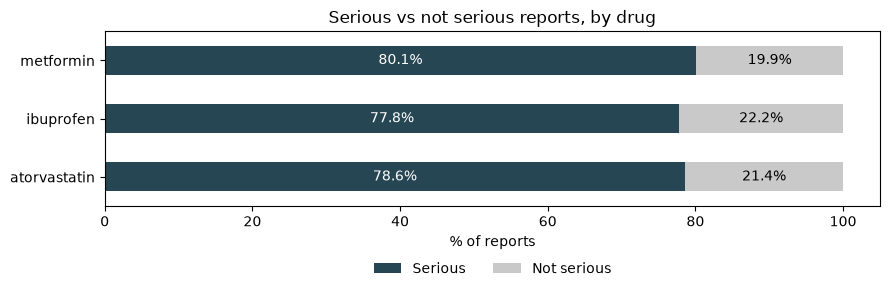

In [24]:
ax = balance.plot.barh(stacked=True, figsize=(9, 3.2), color=["#264653", "#C9C9C9"])
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", label_type="center",
                 color="white" if c is ax.containers[0] else "black")
ax.set_xlabel("% of reports")
ax.set_ylabel("")
ax.set_title("Serious vs not serious reports, by drug")
plt.legend(title="", loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=2, frameon=False)
plt.tight_layout()
plt.savefig("results/serious_vs_not_by_drug.png", dpi=150, bbox_inches="tight")
plt.show()

**Takeaway:** Between 77% and 80% of reports are serious for all three drugs
(metformin 80.1%, atorvastatin 77.9%, ibuprofen 77.2%). The gaps are about
3 percentage points or less, which is within the noise for samples of this
size, so seriousness alone does not separate the drugs. This high share reflects **reporting bias**:
serious events are reported far more often than mild ones. It does not mean
that most people taking these drugs have a serious event.

## Data Analysis

### Which drug has the most serious reports, and what kind?

aboved section showed how many reports are serious. Here we ask what *kind* of
serious outcome each drug has. All percentages are **% of that drug's reports**
(counted per report). The five outcome flags overlap, since one report can be
both "hospitalization" and "life-threatening", so the columns do not add up to
100%. `other_serious` means the report is serious but none of the five flags is
ticked.

In [25]:
rate_cols = outcome_cols + ["other_serious"]

q1 = reports.groupby("queried_drug")[rate_cols].mean().mul(100).round(1)
q1.insert(0, "any_serious", reports.groupby("queried_drug")["serious"]
          .apply(lambda s: (s == 1).mean() * 100).round(1))
q1["n_reports"] = reports.groupby("queried_drug").size()

q1 = q1.rename(columns={
    "seriousnessdeath": "death",
    "seriousnesshospitalization": "hospitalization",
    "seriousnesslifethreatening": "life_threatening",
    "seriousnessdisabling": "disabling",
    "seriousnesscongenitalanomali": "congenital_anomaly",
})
q1

,any_serious,death,hospitalization,life_threatening,disabling,congenital_anomaly,other_serious,n_reports
queried_drug,,,,,,,,
atorvastatin,78.6,5.7,36.9,5.8,5.4,0.0,32.8,2000
ibuprofen,77.8,6.7,37.7,6.4,4.0,1.2,32.2,2000
metformin,80.1,8.8,41.4,7.4,4.7,0.7,27.6,2000


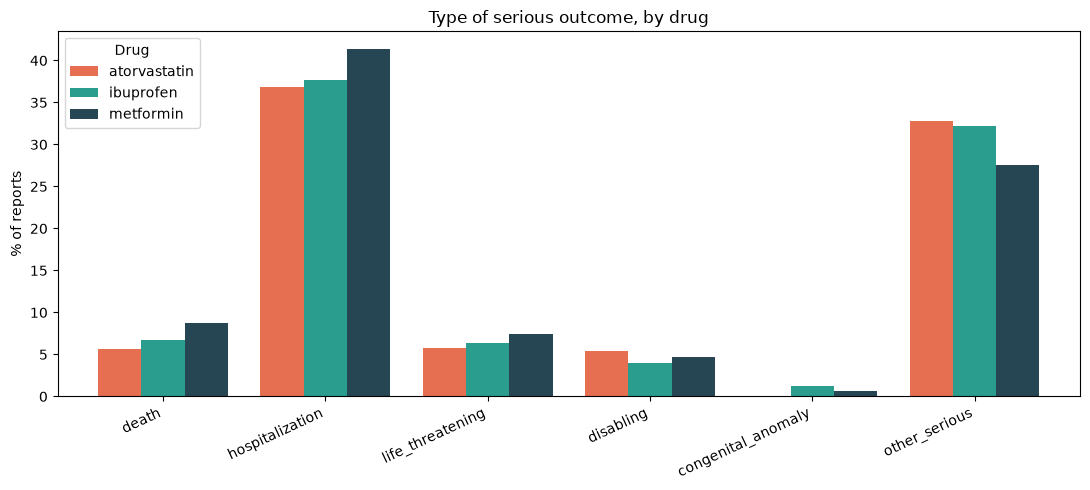

In [26]:
plot_cols = ["death", "hospitalization", "life_threatening",
             "disabling", "congenital_anomaly", "other_serious"]

plot_df = q1[plot_cols].T
ax = plot_df.plot.bar(
    figsize=(11, 5),
    width=0.8,
    color=[drug_colors[d] for d in plot_df.columns],
)
ax.set_ylabel("% of reports")
ax.set_title("Type of serious outcome, by drug")
ax.set_xlabel("")
plt.xticks(rotation=25, ha="right")
plt.legend(title="Drug")
plt.tight_layout()
plt.savefig("results/outcome_types_by_drug.png", dpi=150, bbox_inches="tight")
plt.show()

**Takeaway:** Hospitalization is the most common serious outcome for all three
drugs (about 36–41% of reports), and about 28–33% are "other serious".
Metformin has the highest death rate (8.8% vs 6.2% for ibuprofen and
atorvastatin), but the gap is only about 3 percentage points, so it is a hint,
not a confirmed difference. Congenital anomalies are close to zero for all
three drugs. Metformin patients have diabetes and are often older with other
illnesses, so a higher death rate may reflect the patients and not the drug.

In [27]:
for drug in df["queried_drug"].unique():
    print(f"\n--- {drug} ---")
    print(df[df["queried_drug"] == drug]["reaction_term"].value_counts().head(10))


--- metformin ---
reaction_term
Diarrhoea              117
Drug ineffective       113
Drug interaction       103
Dyspnoea                95
Renal failure acute     95
Nausea                  87
Lactic acidosis         85
Pain                    82
Fatigue                 78
Vomiting                77
Name: count, dtype: int64

--- ibuprofen ---
reaction_term
Pain                     139
Nausea                   113
Drug interaction         113
Drug ineffective         110
Vomiting                 101
Headache                  94
Fatigue                   86
Dyspnoea                  84
Drug hypersensitivity     79
Diarrhoea                 76
Name: count, dtype: int64

--- atorvastatin ---
reaction_term
Type 2 diabetes mellitus    155
Drug ineffective            106
Dyspnoea                    100
Myalgia                      99
Nausea                       94
Fatigue                      89
Diarrhoea                    82
Dizziness                    77
Pain in extremity            7

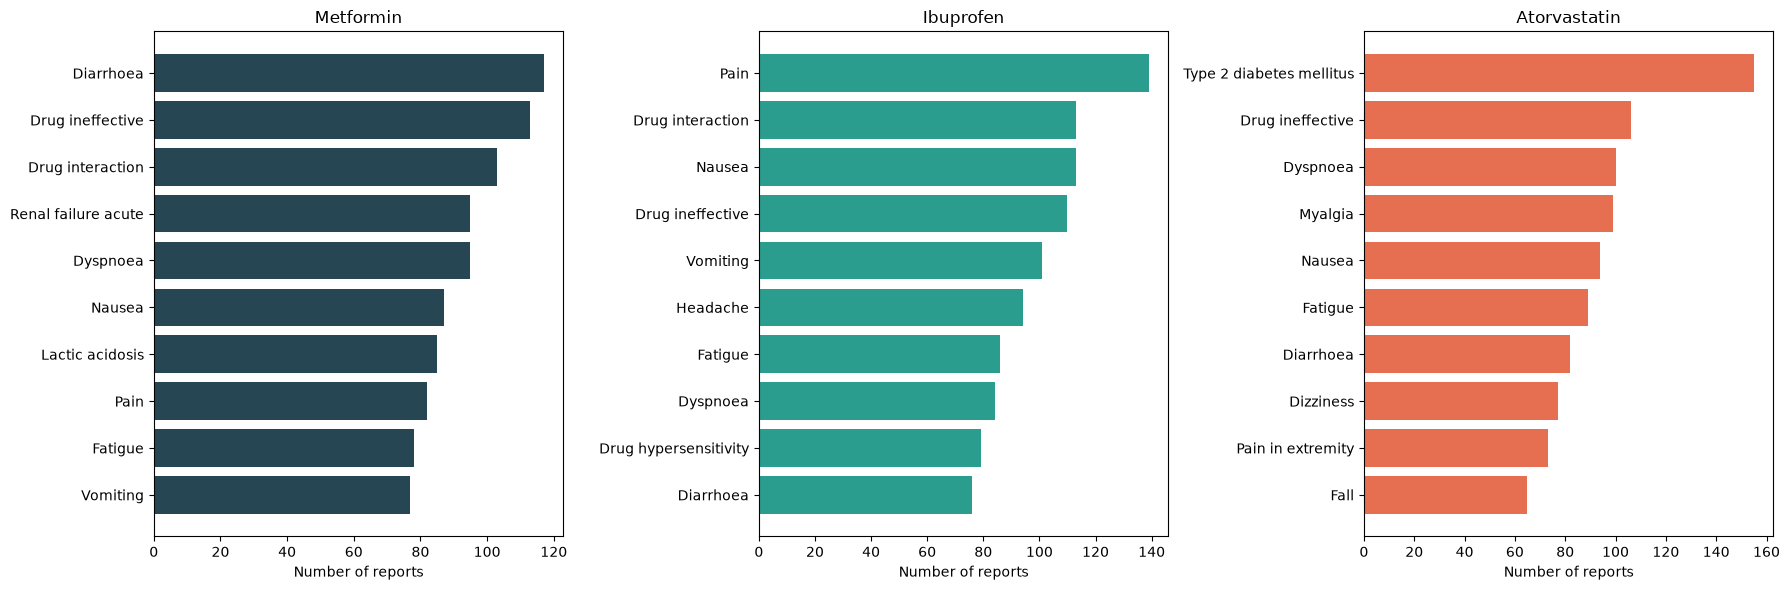

In [28]:
drugs = df["queried_drug"].unique()
fig, axes = plt.subplots(1, len(drugs), figsize=(18, 6), sharey=False)

for ax, drug in zip(axes, drugs):
    top10 = (
        df[df["queried_drug"] == drug]["reaction_term"]
        .value_counts()
        .head(10)
        .sort_values()
    )
    ax.barh(top10.index, top10.values, color=drug_colors[drug])
    ax.set_title(drug.capitalize())
    ax.set_xlabel("Number of reports")

plt.tight_layout()
plt.savefig("results/top_reactions_by_drug.png", dpi=150, bbox_inches="tight")
plt.show()

**Takeaway:** Some reactions appear for every drug (nausea, fatigue, diarrhoea,
"drug ineffective"), so they say little about any one drug. The useful signals
are the reactions specific to each drug, and they match known drug safety
information: metformin shows acute renal failure (95 reports) and lactic
acidosis (85), atorvastatin shows myalgia (94) and muscle spasms (57), and
ibuprofen shows drug hypersensitivity (79) and pulmonary embolism (70).
Atorvastatin's most common reaction is type 2 diabetes mellitus (153 reports),
which fits a documented link between statins and diabetes. This chart shows how
often reactions were reported, not how likely they are: a common drug produces
more reports, and voluntary reporting means these counts are not true risk.

### Does administration route predict severity?

`drug_routes_on_report` can hold several route codes joined by `;` (a
report can list drugs given through different routes). Comparing route vs.
severity on the raw joined string would mix up combinations, so we isolate
reports with exactly **one** distinct route code -- clean, unambiguous cases
only. Reports with mixed routes are set aside for this question only, not
dropped from the main dataset.

In [29]:
def distinct_routes(routes_str):
    if pd.isna(routes_str):
        return set()
    return set(r.strip() for r in routes_str.split(";") if r.strip())

df["route_set"] = df["drug_routes_on_report"].apply(distinct_routes)
df["route_count"] = df["route_set"].apply(len)

print(df["route_count"].value_counts().sort_index())

route_count
1    16441
2     5101
3     1586
4      557
5      192
6      126
7        8
8        2
Name: count, dtype: int64


In [30]:
single_route = df[df["route_count"] == 1].copy()
single_route["route_code"] = single_route["route_set"].apply(lambda s: next(iter(s)))

print(f"Using {len(single_route)} of {len(df)} rows ({len(single_route)/len(df):.1%}) for this question")

Using 16441 of 24013 rows (68.5%) for this question


### What is the reaction outcome distribution per drug?

### What are the most common reactions per drug?

### Which countries report the most events?

### Do age and sex patterns differ?

## Conclusion

### Key Findings

#### Data quality
- Started with 24,333 rows (one row per report–reaction pair). Removed 1,400 duplicate rows (5.8%), leaving 22,933.
- Patient age was stored with a separate unit code (decade, year, month, week, day, hour). Converting everything to years fixed impossible values (max age went from 29,866 to 98).
- Missing values were kept, not dropped: reaction outcome (19%), country (16%), route (14%), age (14%), sex (<1%). Each analysis uses only the columns it needs.

#### Which drug has the most serious reports, and what kind?
- Almost all reports are serious, and the three drugs look similar overall (any serious: 77-80% per drug).
- **Hospitalization** is the most common serious outcome for all three drugs (≈36–41% of reports), followed by "other serious" (≈28–33%).
- **Metformin** has the highest death rate (≈9% vs ≈6% for the others) and the highest hospitalization rate. The death gap is only about 3 points, so treat it as a hint, not a confirmed difference.
- **Congenital anomalies** are close to zero for all three drugs.
- People taking metformin have diabetes and are often older with other illnesses, so this gap may reflect the patients and not the drug.

#### Does the route of administration relate to severity?
Compared reports with a single route (68% of rows), routes with at least 30 reports.

| Route | Serious rate | Reports |
|---|---|---|
| Transdermal (patches) | 22% | 221 |
| Topical (creams) | 56% | 90 |
| Oral | 82% | 7,930 |
| Subcutaneous | 86% | 581 |
| Inhalation | 88% | 322 |
| Intravenous (not specified) | 92% | 490 |

- **Patches and creams had much lower serious rates than pills or IV drugs.** This fits the idea that they release less drug into the whole body.
- Reports with an "unknown" route (coded or missing) were set aside because they are not real routes.



#### Limitations
- FAERS is **voluntary reporting**. It shows what people chose to report, not the true rate of harm, and serious cases are reported more often.
- The route column lists the routes of **every drug on a report**, not only the queried drug, so route findings describe reports, not one drug.
- Many reports list several drugs, so a reaction cannot always be linked to one drug.
- These are **associations, not causes**.